# CNN Lab: Image Classification for Crop Disease Detection

## Lab Overview: Why Crop Disease Detection Matters

**The Challenge**: Crop diseases cause up to 40% of global crop losses annually, threatening food security for millions of people. Early detection is critical but requires expert knowledge that may not be available in remote or resource-constrained regions where WFP operates.

**The Solution**: Deep learning-powered image classification can democratize disease detection, enabling:
- **Farmers** to identify diseases using smartphone cameras
- **Agricultural extension workers** to diagnose problems in the field
- **WFP field officers** to assess crop health rapidly during assessments
- **Early intervention** before diseases spread across entire fields

**This Lab**: We'll build a CNN to classify tomato leaf diseases from images. Tomatoes are a critical crop in many food-insecure regions, and diseases like early blight, late blight, and leaf mold can devastate harvests.

### What Makes This Different from General Image Classification?

Agricultural disease detection has unique challenges:
- **Similar visual symptoms** across different diseases
- **Variable image quality** from field conditions (lighting, angle, focus)
- **Class imbalance** (healthy leaves are more common than diseased)
- **Need for high confidence** (false negatives = crop loss; false positives = unnecessary treatment)
- **Mobile deployment** required for field use

## 🍅 Use Case: Tomato Leaf Disease Classification

**Problem Statement**: Develop an automated system to identify tomato diseases from leaf images, supporting WFP's food security assessments and farmer training programs.

**Dataset**: PlantVillage Tomato Leaf Disease Dataset  

**Classes** (10 categories):
1. Tomato_Bacterial_spot
2. Tomato_Early_blight
3. Tomato_Late_blight
4. Tomato_Leaf_Mold
5. Tomato_Septoria_leaf_spot
6. Tomato_Spider_mites_Two_spotted_spider_mite
7. Tomato_Target_Spot
8. Tomato_Tomato_Yellow_Leaf_Curl_Virus
9. Tomato_Tomato_mosaic_virus
10. Tomato_healthy

**Impact**: Early detection allows farmers to:
- Apply targeted treatments quickly
- Prevent disease spread
- Reduce crop losses by up to 30%
- Make informed decisions about harvest timing

## Setup and Dependencies

In [ ]:
# Install required packages
#!pip install -q tensorflow matplotlib numpy pillow scikit-learn seaborn

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

In [21]:
# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import plot_model

In [22]:
# Utilities
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import json
from pathlib import Path

In [23]:
# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("=" * 70)
print("ENVIRONMENT SETUP COMPLETE")
print("=" * 70)
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU'))} GPU(s)")
print(f"Eager Execution: {tf.executing_eagerly()}")
print("=" * 70)

ENVIRONMENT SETUP COMPLETE
TensorFlow version: 2.21.0
GPU Available: 0 GPU(s)
Eager Execution: True


In [24]:
# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Dataset Download and Preparation

Dataset Structure:

```

PlantVillage/
├── train/
│   ├── Tomato___Bacterial_spot/
│   ├── Tomato___Early_blight/
│   ├── Tomato___Late_blight/
│   ├── Tomato___Leaf_Mold/
│   ├── Tomato___Septoria_leaf_spot/
│   ├── Tomato___Spider_mites Two-spotted_spider_mite/
│   ├── Tomato___Target_Spot/
│   ├── Tomato___Tomato_Yellow_Leaf_Curl_Virus/
│   ├── Tomato___Tomato_mosaic_virus/
│   └── Tomato___healthy/
└── valid/
    └── (same structure)
```



In [25]:
# Configuration
BASE_DIR = "PlantVillage"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VALID_DIR = os.path.join(BASE_DIR, "valid")

IMG_SIZE = 128
BATCH_SIZE = 32
CHANNELS = 3

In [30]:
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VALID_DIR = os.path.join(BASE_DIR, "valid")

# Check if dataset exists
if os.path.exists(TRAIN_DIR) and os.path.exists(VALID_DIR):
    print(f"Dataset found in: {BASE_DIR}")
else:
    raise FileNotFoundError("Train or validation directory not found")

print(f"\nTrain directory: {TRAIN_DIR}")
print(f"Validation directory: {VALID_DIR}")



Dataset found in: PlantVillage

Train directory: PlantVillage\train
Validation directory: PlantVillage\valid


### Explore Dataset Structure

In [33]:
os.listdir("PlantVillage")

['train', 'valid']

In [31]:
# Count images per class
def count_images_per_class(directory):
    """Count images in each class folder"""
    class_counts = {}

    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            # Filter only tomato classes
            if class_name.startswith('Tomato'):
                count = len([f for f in os.listdir(class_path)
                           if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
                # Clean class name for display
                clean_name = class_name.replace('Tomato___', '').replace('_', ' ')
                class_counts[clean_name] = count

    return class_counts

In [35]:

# Get class counts
train_counts = count_images_per_class(TRAIN_DIR)
valid_counts = count_images_per_class(VALID_DIR)

In [36]:
print("=" * 70)
print("DATASET STATISTICS")
print("=" * 70)
print(f"Number of disease classes: {len(train_counts)}")
print(f"Total training images: {sum(train_counts.values())}")
print(f"Total validation images: {sum(valid_counts.values())}")

DATASET STATISTICS
Number of disease classes: 10
Total training images: 14529
Total validation images: 3631


In [38]:
print("\nTraining set distribution:")
for disease, count in sorted(train_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"  {disease:40s}: {count:4d} images")


Training set distribution:
  Tomato Yellow Leaf Curl Virus           : 4286 images
  Bacterial spot                          : 1702 images
  Late blight                             : 1527 images
  Septoria leaf spot                      : 1417 images
  Spider mites Two-spotted spider mite    : 1341 images
  healthy                                 : 1273 images
  Target Spot                             : 1123 images
  Early blight                            :  800 images
  Leaf Mold                               :  761 images
  Tomato mosaic virus                     :  299 images


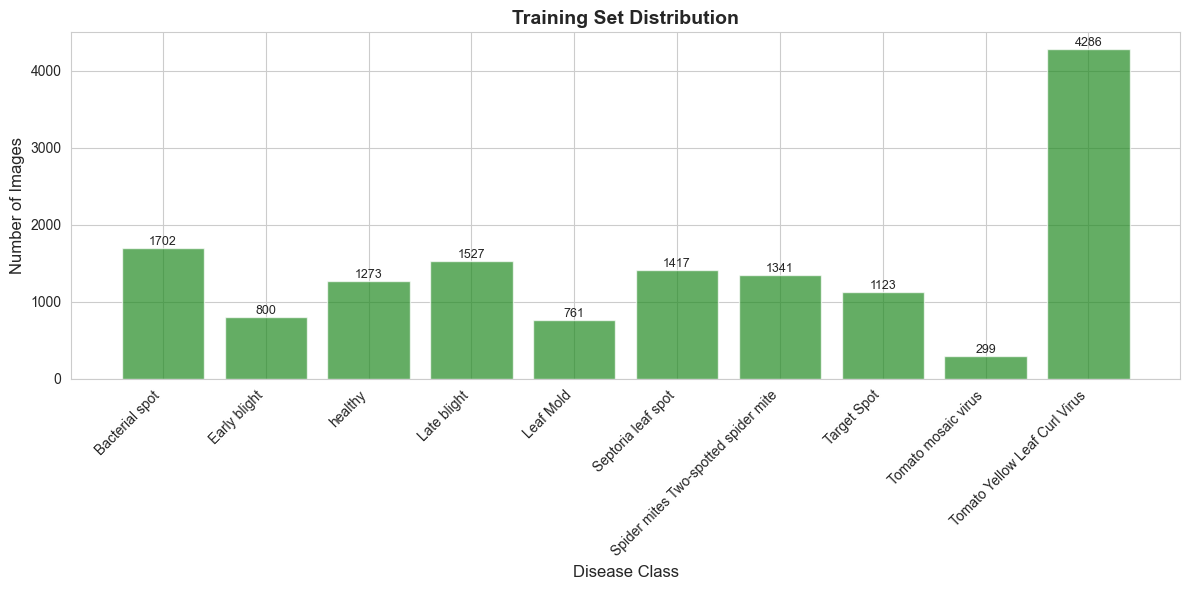

In [39]:

# Visualize class distribution
fig, ax = plt.subplots(figsize=(12, 6))
diseases = list(train_counts.keys())
counts = list(train_counts.values())

bars = ax.bar(range(len(diseases)), counts, color='forestgreen', alpha=0.7)
ax.set_xlabel('Disease Class', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Training Set Distribution', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(diseases)))
ax.set_xticklabels(diseases, rotation=45, ha='right')

# Add value labels on bars
for i, (bar, count) in enumerate(zip(bars, counts)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(count)}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [41]:
# Check for class imbalance
max_count = max(train_counts.values())
min_count = min(train_counts.values())
imbalance_ratio = max_count / min_count
print(f"\nClass imbalance ratio: {imbalance_ratio:.2f}:1")
if imbalance_ratio > 3:
    print(" Significant class imbalance detected - consider using class weights")


Class imbalance ratio: 14.33:1
 Significant class imbalance detected - consider using class weights


### Visualize Sample Images

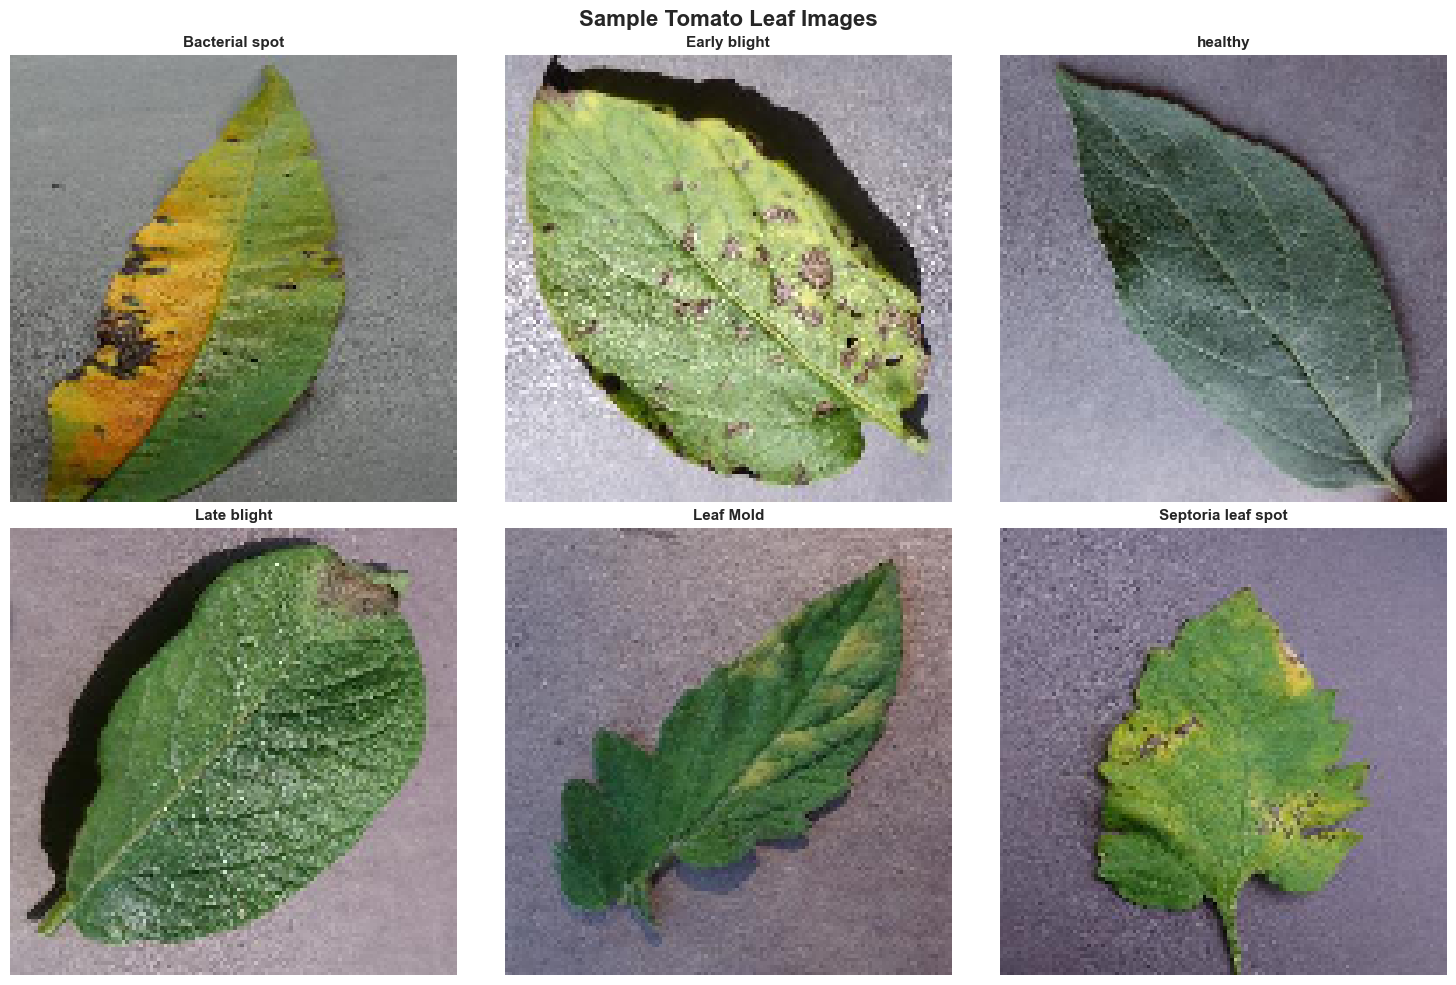

In [42]:
# Display sample images from each disease class
def plot_disease_samples(data_dir, diseases, n_samples=6):
    """Display sample images from disease classes"""
    n_diseases = min(len(diseases), 6)
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for idx, disease in enumerate(diseases[:n_diseases]):
        # Find corresponding folder (with underscores)
        disease_folder = None
        for folder in os.listdir(data_dir):
            if disease.replace(' ', '_') in folder or disease.replace(' ', '') in folder:
                disease_folder = folder
                break

        if disease_folder:
            disease_path = os.path.join(data_dir, disease_folder)
            images = [f for f in os.listdir(disease_path)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

            if images:
                # Load random image
                img_path = os.path.join(disease_path, np.random.choice(images))
                img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))

                axes[idx].imshow(img)
                axes[idx].set_title(disease, fontsize=11, fontweight='bold')
                axes[idx].axis('off')

    plt.suptitle('Sample Tomato Leaf Images', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_disease_samples(TRAIN_DIR, list(train_counts.keys()))


## Data Preprocessing and Augmentation

In [43]:

# Data augmentation for training (critical for disease detection)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,  # Leaves can be at any angle
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,  # Leaves have no fixed orientation
    brightness_range=[0.7, 1.3],  # Account for varying field conditions
    fill_mode='nearest'
)

# Validation data - only rescaling
valid_datagen = ImageDataGenerator(rescale=1./255)

print("Data Augmentation Strategy for Disease Detection:")
print("=" * 70)
print("Rotation (±40°): Leaves photographed from any angle")
print("Flips: No fixed leaf orientation in field conditions")
print("Zoom: Variable distance from leaf surface")
print("Brightness: Different lighting conditions and times of day")
print("Shifts & Shear: Simulate handheld camera movement")
print("=" * 70)

Data Augmentation Strategy for Disease Detection:
Rotation (±40°): Leaves photographed from any angle
Flips: No fixed leaf orientation in field conditions
Zoom: Variable distance from leaf surface
Brightness: Different lighting conditions and times of day
Shifts & Shear: Simulate handheld camera movement


### Create Data Generators

In [45]:

# Training generator
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

# Validation generator
valid_generator = valid_datagen.flow_from_directory(
    VALID_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Extract class information
class_indices = train_generator.class_indices
class_names = {v: k.replace('Tomato___', '').replace('_', ' ')
               for k, v in class_indices.items()}
NUM_CLASSES = len(class_names)

print("\nData Generators Summary:")
print("=" * 70)
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {valid_generator.samples}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Steps per epoch: {len(train_generator)}")
print(f"Validation steps: {len(valid_generator)}")
print("=" * 70)

print("\nClass mapping:")
for idx, name in sorted(class_names.items()):
    print(f"  {idx}: {name}")

Found 43444 images belonging to 38 classes.
Found 10861 images belonging to 38 classes.

Data Generators Summary:
Training samples: 43444
Validation samples: 10861
Number of classes: 38
Batch size: 32
Steps per epoch: 1358
Validation steps: 340

Class mapping:
  0: Apple   Apple scab
  1: Apple   Black rot
  2: Apple   Cedar apple rust
  3: Apple   healthy
  4: Blueberry   healthy
  5: Cherry (including sour)   Powdery mildew
  6: Cherry (including sour)   healthy
  7: Corn (maize)   Cercospora leaf spot Gray leaf spot
  8: Corn (maize)   Common rust 
  9: Corn (maize)   Northern Leaf Blight
  10: Corn (maize)   healthy
  11: Grape   Black rot
  12: Grape   Esca (Black Measles)
  13: Grape   Leaf blight (Isariopsis Leaf Spot)
  14: Grape   healthy
  15: Orange   Haunglongbing (Citrus greening)
  16: Peach   Bacterial spot
  17: Peach   healthy
  18: Pepper, bell   Bacterial spot
  19: Pepper, bell   healthy
  20: Potato   Early blight
  21: Potato   Late blight
  22: Potato   healthy
 

### Visualize Augmented Images

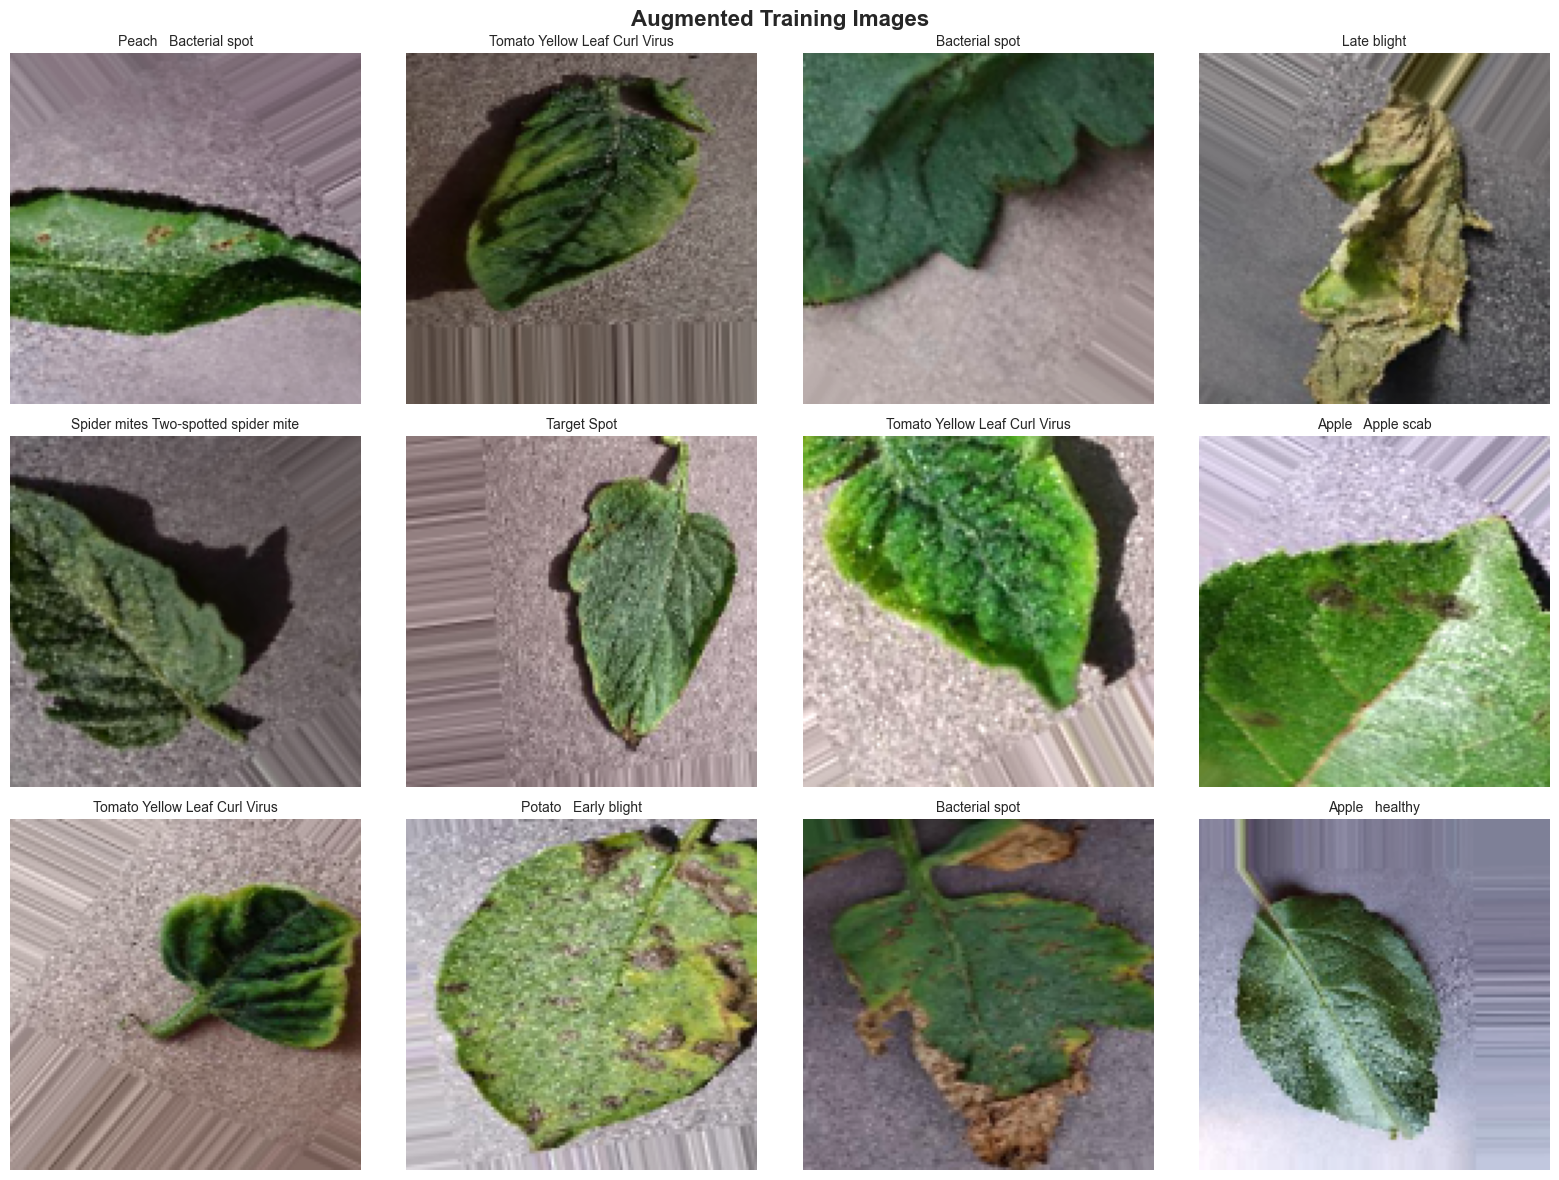

In [46]:


# Show augmentation effects
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

# Get one batch
images, labels = next(train_generator)

for i, (img, label) in enumerate(zip(images[:12], labels[:12])):
    axes[i].imshow(img)
    class_idx = np.argmax(label)
    class_name = class_names[class_idx]
    axes[i].set_title(class_name, fontsize=10)
    axes[i].axis('off')

plt.suptitle('Augmented Training Images', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Building the CNN for Disease Detection

In [47]:
def create_disease_detection_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                                  num_classes=NUM_CLASSES):
    """
    Build CNN optimized for crop disease detection

    Architecture considerations:
    - Multiple conv layers to capture disease patterns at different scales
    - Batch normalization for stable training
    - Dropout for regularization (limited training data)
    - Global average pooling to reduce parameters
    """

    model = models.Sequential(name='TomatoDisease_CNN')

    # Block 1: Learn basic features (edges, colors)
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                           input_shape=input_shape, name='conv1_1'))
    model.add(layers.BatchNormalization(name='bn1_1'))
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv1_2'))
    model.add(layers.BatchNormalization(name='bn1_2'))
    model.add(layers.MaxPooling2D((2, 2), name='pool1'))
    model.add(layers.Dropout(0.25, name='dropout1'))

    # Block 2: Learn texture patterns (spots, lesions)
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2_1'))
    model.add(layers.BatchNormalization(name='bn2_1'))
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2_2'))
    model.add(layers.BatchNormalization(name='bn2_2'))
    model.add(layers.MaxPooling2D((2, 2), name='pool2'))
    model.add(layers.Dropout(0.25, name='dropout2'))

    # Block 3: Learn complex disease signatures
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3_1'))
    model.add(layers.BatchNormalization(name='bn3_1'))
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3_2'))
    model.add(layers.BatchNormalization(name='bn3_2'))
    model.add(layers.MaxPooling2D((2, 2), name='pool3'))
    model.add(layers.Dropout(0.3, name='dropout3'))

    # Classification head
    model.add(layers.Flatten(name='flatten'))
    model.add(layers.Dense(256, activation='relu', name='dense1'))
    model.add(layers.BatchNormalization(name='bn4'))
    model.add(layers.Dropout(0.5, name='dropout4'))
    model.add(layers.Dense(num_classes, activation='softmax', name='output'))

    return model

# Create model
model = create_disease_detection_cnn()

# Compile with appropriate metrics for disease detection
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_accuracy'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

print("=" * 70)
print("CNN MODEL FOR TOMATO DISEASE DETECTION")
print("=" * 70)
model.summary()

print(f"\nModel Configuration:")
print(f"Total parameters: {model.count_params():,}")
print(f"Input shape: {IMG_SIZE}x{IMG_SIZE}x{CHANNELS}")
print(f"Output classes: {NUM_CLASSES}")
print(f"Optimizer: Adam (lr=0.001)")
print(f"Loss: Categorical Crossentropy")

CNN MODEL FOR TOMATO DISEASE DETECTION


Model: "TomatoDisease_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1_1 (Conv2D)                     │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn1_1 (BatchNormalization)           │ (None, 128, 128, 32)        │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1_2 (Conv2D)                     │ (None, 128, 128, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn1_2 (BatchNormalization)           │ (None, 128, 128, 32)        │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool1 (MaxPooling2D)                 │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout1 (Dropout)                   │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2_1 (Conv2D)                     │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn2_1 (BatchNormalization)           │ (None, 64, 64, 64)          │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2_2 (Conv2D)                     │ (None, 64, 64, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn2_2 (BatchNormalization)           │ (None, 64, 64, 64)          │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool2 (MaxPooling2D)                 │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout2 (Dropout)                   │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3_1 (Conv2D)                     │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn3_1 (BatchNormalization)           │ (None, 32, 32, 128)         │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3_2 (Conv2D)                     │ (None, 32, 32, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn3_2 (BatchNormalization)           │ (None, 32, 32, 128)         │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool3 (MaxPooling2D)                 │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout3 (Dropout)                   │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense1 (Dense)                       │ (None, 256)                 │       8,388,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn4 (BatchNormalization)             │ (None, 256)                 │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 8,688,454 (33.14 MB)

 Trainable params: 8,687,046 (33.14 MB)

 Non-trainable params: 1,408 (5.50 KB)


Model Configuration:
Total parameters: 8,688,454
Input shape: 128x128x3
Output classes: 38
Optimizer: Adam (lr=0.001)
Loss: Categorical Crossentropy


### Visualize Model Architecture

In [50]:
#pip install pydot

In [51]:
# Plot model architecture
try:
    plot_model(model, to_file='disease_detection_cnn.png',
               show_shapes=True, show_layer_names=True, dpi=96)
    print(" Model architecture saved as 'disease_detection_cnn.png'")
except:
    print(" Could not generate architecture diagram (pydot not installed)")

# Display layer structure
print("\nLayer-by-Layer Feature Transformation:")
print("=" * 70)
for i, layer in enumerate(model.layers):
    if hasattr(layer, 'output_shape'):
        print(f"{i+1:2d}. {layer.name:20s} → {str(layer.output_shape):30s}")

You must install pydot (`pip install pydot`) for `plot_model` to work.
 Model architecture saved as 'disease_detection_cnn.png'

Layer-by-Layer Feature Transformation:


## Training the Disease Detection Model

In [ ]:

# Calculate class weights for imbalanced dataset
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

print("Class Weights (to handle imbalance):")
for idx, weight in class_weight_dict.items():
    print(f"  {class_names[idx]:40s}: {weight:.3f}")

# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_tomato_disease_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Custom callback for progress updates
class TrainingMonitor(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 5 == 0:
            print(f"\nEpoch {epoch+1} Summary:")
            print(f"  Train Acc: {logs['accuracy']:.4f} | Val Acc: {logs['val_accuracy']:.4f}")
            print(f"  Train Loss: {logs['loss']:.4f} | Val Loss: {logs['val_loss']:.4f}")
            print(f"  Precision: {logs['precision']:.4f} | Recall: {logs['recall']:.4f}")

# Train the model
print("\n" + "=" * 70)
print("TRAINING CNN FOR TOMATO DISEASE DETECTION")
print("=" * 70)
print("This may take 10-20 minutes depending on hardware...")
print("=" * 70)

EPOCHS = 50

history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    validation_data=valid_generator,
    validation_steps=len(valid_generator),
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr, checkpoint, TrainingMonitor()],
    verbose=1
)

print("\n Training complete!")
print(f"Total epochs trained: {len(history.history['loss'])}")

Class Weights (to handle imbalance):
  Apple   Apple scab                      : 2.268
  Apple   Black rot                       : 2.305
  Apple   Cedar apple rust                : 5.197
  Apple   healthy                         : 0.869
  Blueberry   healthy                     : 0.951
  Cherry (including sour)   Powdery mildew: 1.358
  Cherry (including sour)   healthy       : 1.671
  Corn (maize)   Cercospora leaf spot Gray leaf spot: 2.788
  Corn (maize)   Common rust              : 1.200
  Corn (maize)   Northern Leaf Blight     : 1.451
  Corn (maize)   healthy                  : 1.231
  Grape   Black rot                       : 1.211
  Grape   Esca (Black Measles)            : 1.033
  Grape   Leaf blight (Isariopsis Leaf Spot): 1.328
  Grape   healthy                         : 3.372
  Orange   Haunglongbing (Citrus greening): 0.260
  Peach   Bacterial spot                  : 0.622
  Peach   healthy                         : 3.970
  Pepper, bell   Bacterial spot           : 1.434
 


Epoch 1: finished saving model to best_tomato_disease_model.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 2211s 2s/step - accuracy: 0.4131 - loss: 2.0793 - precision: 0.6409 - recall: 0.2693 - top3_accuracy: 0.6530 - val_accuracy: 0.4925 - val_loss: 2.0379 - val_precision: 0.5992 - val_recall: 0.4342 - val_top3_accuracy: 0.7230 - learning_rate: 0.0010
Epoch 2/50
 327/1358 ━━━━━━━━━━━━━━━━━━━━ 25:00 1s/step - accuracy: 0.5907 - loss: 1.3037 - precision: 0.7447 - recall: 0.4625 - top3_accuracy: 0.8328

### Visualize Training Progress

In [ ]:

# Plot comprehensive training history
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Accuracy
axes[0, 0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0, 0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0, 0].set_title('Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss
axes[0, 1].plot(history.history['loss'], label='Train', linewidth=2)
axes[0, 1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[0, 1].set_title('Loss', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Top-3 Accuracy
axes[0, 2].plot(history.history['top3_accuracy'], label='Train', linewidth=2)
axes[0, 2].plot(history.history['val_top3_accuracy'], label='Validation', linewidth=2)
axes[0, 2].set_title('Top-3 Accuracy', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Top-3 Accuracy')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Precision
axes[1, 0].plot(history.history['precision'], label='Train', linewidth=2)
axes[1, 0].plot(history.history['val_precision'], label='Validation', linewidth=2)
axes[1, 0].set_title('Precision', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Recall
axes[1, 1].plot(history.history['recall'], label='Train', linewidth=2)
axes[1, 1].plot(history.history['val_recall'], label='Validation', linewidth=2)
axes[1, 1].set_title('Recall', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Learning rate (if available)
if 'lr' in history.history:
    axes[1, 2].plot(history.history['lr'], linewidth=2, color='purple')
    axes[1, 2].set_title('Learning Rate', fontsize=12, fontweight='bold')
    axes[1, 2].set_xlabel('Epoch')
    axes[1, 2].set_ylabel('Learning Rate')
    axes[1, 2].set_yscale('log')
    axes[1, 2].grid(True, alpha=0.3)
else:
    axes[1, 2].axis('off')

plt.suptitle('Training History - Tomato Disease Detection CNN',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print final metrics
print("\nFinal Training Metrics:")
print("=" * 70)
print(f"Training Accuracy:    {history.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy:  {history.history['val_accuracy'][-1]:.4f}")
print(f"Training Loss:        {history.history['loss'][-1]:.4f}")
print(f"Validation Loss:      {history.history['val_loss'][-1]:.4f}")
print(f"Precision:            {history.history['val_precision'][-1]:.4f}")
print(f"Recall:               {history.history['val_recall'][-1]:.4f}")
print("=" * 70)

## Model Evaluation and Analysis

In [ ]:

# Evaluate on validation set
print("Evaluating model on validation set...")
val_results = model.evaluate(valid_generator, verbose=0)

print("\n" + "=" * 70)
print("VALIDATION SET PERFORMANCE")
print("=" * 70)
metric_names = model.metrics_names
for name, value in zip(metric_names, val_results):
    if 'accuracy' in name:
        print(f"{name:20s}: {value:.4f} ({value*100:.2f}%)")
    else:
        print(f"{name:20s}: {value:.4f}")
print("=" * 70)

# Generate predictions
print("\nGenerating predictions for confusion matrix...")
valid_generator.reset()
predictions = model.predict(valid_generator, steps=len(valid_generator), verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = valid_generator.classes

# Classification report
print("\n" + "=" * 70)
print("DETAILED CLASSIFICATION REPORT")
print("=" * 70)
class_names_list = [class_names[i] for i in range(NUM_CLASSES)]
print(classification_report(true_classes, predicted_classes,
                          target_names=class_names_list, digits=4))

### Confusion Matrix

In [ ]:

# Compute confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=class_names_list, yticklabels=class_names_list,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Tomato Disease Detection',
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Disease', fontsize=12)
plt.xlabel('Predicted Disease', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Analyze confusion matrix
print("\nConfusion Matrix Analysis:")
print("=" * 70)
for i in range(NUM_CLASSES):
    total = cm[i].sum()
    correct = cm[i, i]
    accuracy = correct / total if total > 0 else 0
    print(f"{class_names_list[i]:40s}: {correct:3d}/{total:3d} = {accuracy:.2%}")

### Visualize Predictions

In [ ]:

# Visualize predictions with confidence scores
def plot_predictions_with_confidence(generator, model, n_images=12):
    """Display predictions with confidence scores and true labels"""
    generator.reset()
    images, labels = next(generator)
    predictions = model.predict(images, verbose=0)

    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.flatten()

    for i in range(min(n_images, len(images))):
        axes[i].imshow(images[i])

        true_idx = np.argmax(labels[i])
        pred_idx = np.argmax(predictions[i])
        confidence = predictions[i][pred_idx] * 100

        true_disease = class_names[true_idx]
        pred_disease = class_names[pred_idx]

        # Color code: green if correct, red if wrong
        color = 'green' if true_idx == pred_idx else 'red'

        # Show top 3 predictions
        top_3_idx = np.argsort(predictions[i])[-3:][::-1]
        top_3_text = '\n'.join([f"{class_names[idx]}: {predictions[i][idx]*100:.1f}%"
                                for idx in top_3_idx])

        title = f'True: {true_disease}\nPred: {pred_disease}\nConf: {confidence:.1f}%'
        axes[i].set_title(title, color=color, fontsize=9)
        axes[i].axis('off')

    plt.suptitle('Disease Detection Predictions', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_predictions_with_confidence(valid_generator, model)

### Analyze Model Confidence

In [ ]:
# Analyze prediction confidence distribution
valid_generator.reset()
all_predictions = model.predict(valid_generator, steps=len(valid_generator))
max_confidences = np.max(all_predictions, axis=1)
predicted_classes_all = np.argmax(all_predictions, axis=1)
correct_predictions = predicted_classes_all == valid_generator.classes

# Plot confidence distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall confidence distribution
axes[0].hist(max_confidences, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(max_confidences.mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {max_confidences.mean():.3f}')
axes[0].set_xlabel('Prediction Confidence', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Prediction Confidences', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Confidence for correct vs incorrect predictions
axes[1].hist(max_confidences[correct_predictions], bins=30, alpha=0.7,
            label='Correct', color='green', edgecolor='black')
axes[1].hist(max_confidences[~correct_predictions], bins=30, alpha=0.7,
            label='Incorrect', color='red', edgecolor='black')
axes[1].set_xlabel('Prediction Confidence', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Confidence: Correct vs Incorrect Predictions',
                  fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nConfidence Analysis:")
print("=" * 70)
print(f"Mean confidence (all):       {max_confidences.mean():.4f}")
print(f"Mean confidence (correct):   {max_confidences[correct_predictions].mean():.4f}")
print(f"Mean confidence (incorrect): {max_confidences[~correct_predictions].mean():.4f}")
print(f"Predictions with >90% conf:  {(max_confidences > 0.9).sum()} ({(max_confidences > 0.9).sum()/len(max_confidences)*100:.1f}%)")
print(f"Predictions with <50% conf:  {(max_confidences < 0.5).sum()} ({(max_confidences < 0.5).sum()/len(max_confidences)*100:.1f}%)")


## Save Model and Deployment

In [ ]:

# Save complete model
model.save('tomato_disease_detector.h5')
print(" Full model saved as 'tomato_disease_detector.h5'")

# Save in SavedModel format (for production)
model.save('tomato_disease_model')
print(" SavedModel format saved for production deployment")

# Convert to TensorFlow Lite for mobile
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('tomato_disease_detector.tflite', 'wb') as f:
    f.write(tflite_model)
print(" TensorFlow Lite model saved for mobile deployment")

# Save class mapping
class_mapping = {int(k): v for k, v in class_names.items()}
with open('class_mapping.json', 'w') as f:
    json.dump(class_mapping, f, indent=2)
print(" Class mapping saved")

# Save training history
history_df = pd.DataFrame(history.history)
history_df.to_csv('training_history.csv', index=False)
print(" Training history saved")

print(f"\nModel Summary:")
print(f"  Validation Accuracy: {val_results[1]*100:.2f}%")
print(f"  Model size (.h5): {os.path.getsize('tomato_disease_detector.h5') / 1024 / 1024:.2f} MB")
print(f"  TFLite size: {len(tflite_model) / 1024 / 1024:.2f} MB")

### Create Inference Function

In [ ]:

def predict_disease(image_path, model, class_names, threshold=0.6):
    """
    Predict disease from leaf image with confidence threshold

    Args:
        image_path: Path to image or numpy array
        model: Trained model
        class_names: Dictionary of class names
        threshold: Minimum confidence to return prediction

    Returns:
        prediction, confidence, top_3_predictions, certainty_level
    """
    # Load and preprocess image
    if isinstance(image_path, str):
        img = load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
        img_array = img_to_array(img)
    else:
        img_array = image_path
        img = Image.fromarray((img_array * 255).astype(np.uint8))

    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    predictions = model.predict(img_array, verbose=0)[0]
    predicted_idx = np.argmax(predictions)
    confidence = predictions[predicted_idx]

    # Get top 3 predictions
    top_3_idx = np.argsort(predictions)[-3:][::-1]
    top_3_predictions = [(class_names[i], float(predictions[i])) for i in top_3_idx]

    # Determine certainty level
    if confidence >= 0.9:
        certainty = "Very High"
    elif confidence >= 0.7:
        certainty = "High"
    elif confidence >= threshold:
        certainty = "Moderate"
    else:
        certainty = "Low - Manual inspection recommended"

    predicted_disease = class_names[predicted_idx] if confidence >= threshold else "Uncertain"

    return predicted_disease, confidence, top_3_predictions, certainty, img

# Example usage
print("\n" + "=" * 70)
print("EXAMPLE DISEASE PREDICTION")
print("=" * 70)

# Get a test image
valid_generator.reset()
test_images, test_labels = next(valid_generator)
sample_image = test_images[0]
true_label = class_names[np.argmax(test_labels[0])]

# Make prediction
disease, conf, top_3, certainty, display_img = predict_disease(
    sample_image, model, class_names
)

print(f"\nTrue Disease: {true_label}")
print(f"Predicted Disease: {disease}")
print(f"Confidence: {conf*100:.2f}%")
print(f"Certainty Level: {certainty}")
print(f"\nTop 3 Predictions:")
for i, (name, prob) in enumerate(top_3, 1):
    print(f"  {i}. {name:40s}: {prob*100:.2f}%")

In [ ]:


# Display
plt.figure(figsize=(8, 8))
plt.imshow(display_img)
plt.title(f'Predicted: {disease}\nConfidence: {conf*100:.1f}% ({certainty})\nTrue: {true_label}',
          fontsize=12, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()